<a href="https://colab.research.google.com/github/guslimaa777/45419370/blob/main/aula5_visual_detalhada_aluno.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 5 – Versão visual e detalhada

**Curso:** Machine Learning Aplicada à Indústria  
**Versão:** Aluno

## Objetivo
Nesta aula, você irá observar e registrar:
- preparação dos dados de entrada (`X`) e da variável-alvo (`y`);
- padronização da base;
- divisão em treino e validação;
- criação do modelo;
- treino e validação;
- leitura de métricas;
- interpretação dos gráficos.


## 1. Importação das bibliotecas

Execute o bloco abaixo e observe quais bibliotecas estão sendo usadas.

Durante nossa aula, vamos utilizar algumas bibliotecas. Cada uma terá uma função específica no nosso projeto. Vamos conhecê-las uma por uma conforme avançarmos nas etapas.


In [181]:
import pandas as pd # 1. Pandas → carregar e manipular os dados.
import numpy as np # 2. NumPy → trabalhar com cálculos numéricos.
import matplotlib.pyplot as plt # 3. Matplotlib → criar gráficos.
# 4. train_test_split → separar os dados em treino e teste.
# 5. ColumnTransformer → aplicar tratamentos diferentes às colunas.
# 6. Pipeline → organizar as etapas do processamento.
# 7. OneHotEncoder → transformar categorias em números.
# 8. StandardScaler → padronizar os dados numéricos.
# 9. LabelEncoder → transformar categorias em números.
# 10. SimpleImputer → tratar valores ausentes.
# 11. DecisionTreeClassifier → criar o modelo de Árvore de Decisão.
# 12. KMeans → encontrar grupos de dados semelhantes.
# 13. LabelSpreading → classificação semissupervisionda.
# 14. Métricas → avaliar o desempenho dos modelos.
# 14.1 accuracy_score → mede a quantidade de acertos do modelo.
# 14.2 classification_report → apresenta várias métricas de desempenho.
# 14.3 confusion_matrix → mostra os acertos e erros de cada classe.
# 14.4 silhouette_score → avalia a qualidade dos grupos encontrados.

print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


### Registro do aluno
Explique com suas palavras:
- para que serve o Scikit-learn;
- por que ele é importante para Machine Learning.


In [182]:
df = pd.read_csv("/content/base_aula5_tipos_aprendizado_industria.csv")
print("Dimensões da base:", df.shape)
df.head()

Dimensões da base: (240, 19)


,linha_producao,turno,produto_quimico,tipo_valvula,status_sensor,vazao_setpoint_l_min,vazao_real_l_min,erro_vazao_pct,pressao_linha_bar,desvio_pressao_pct,temperatura_produto_c,abertura_valvula_pct,vibracao_bomba_mm_s,ph_produto,consumo_energia_kwh,tempo_resposta_seg,horas_operacao_bomba,status_instrumentacao,acao_ideal_controle
0,Linha_C,Manhã,Base,Borboleta,OK,104.97,115.78,10.30,6.39,10.17,50.19,58.59,2.47,6.37,120.68,2.18,1257,Normal,Reduzir_Abertura
1,Linha_B,Noite,Acido,Esfera,OK,97.21,94.74,-2.54,5.79,-0.17,40.75,26.90,3.79,5.83,143.20,3.59,1892,Normal,Manter_Ajuste
2,Linha_C,Manhã,Acido,Borboleta,OK,100.91,98.73,-2.16,6.26,7.93,37.14,64.77,4.70,7.67,95.72,3.78,2382,Normal,Manter_Ajuste
3,Linha_B,Noite,Acido,Borboleta,Ruido,100.07,93.17,-6.90,5.42,-6.55,38.45,73.44,3.34,5.59,88.30,2.64,2543,Normal,Aumentar_Abertura
4,Linha_A,Tarde,Solvente,Esfera,OK,105.38,93.93,-10.87,7.81,34.66,50.91,40.90,6.47,6.54,143.12,4.23,1401,Falha,Aumentar_Abertura


### Estatisticas do dataset

In [183]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
linha_producao,240,3,Linha_A,86,NaN,NaN,NaN,NaN,NaN,NaN,NaN
turno,240,3,Noite,85,NaN,NaN,NaN,NaN,NaN,NaN,NaN
produto_quimico,240,3,Acido,85,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tipo_valvula,240,3,Borboleta,88,NaN,NaN,NaN,NaN,NaN,NaN,NaN
status_sensor,240,3,OK,174,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vazao_setpoint_l_min,240.0,NaN,NaN,NaN,100.489917,11.62172,56.22,93.9975,100.825,107.5875,133.71
vazao_real_l_min,240.0,NaN,NaN,NaN,100.250458,13.371414,54.96,92.4175,101.025,108.89,135.97
erro_vazao_pct,240.0,NaN,NaN,NaN,-0.269917,6.378737,-23.84,-4.3875,-0.14,3.9125,14.56
pressao_linha_bar,240.0,NaN,NaN,NaN,5.729875,0.948048,3.14,5.11,5.78,6.3125,8.42
desvio_pressao_pct,240.0,NaN,NaN,NaN,-1.209208,16.345756,-45.86,-11.8925,-0.34,8.835,45.17


###Selecionar a variavel<br>

>status_instrumentacao

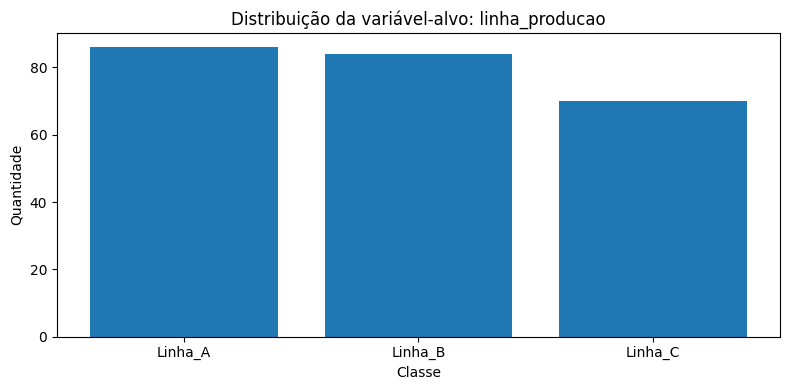

  linha_producao  turno produto_quimico tipo_valvula status_sensor  \
0        Linha_C  Manhã            Base    Borboleta            OK   
1        Linha_B  Noite           Acido       Esfera            OK   
2        Linha_C  Manhã           Acido    Borboleta            OK   
3        Linha_B  Noite           Acido    Borboleta         Ruido   
4        Linha_A  Tarde        Solvente       Esfera            OK   

   vazao_setpoint_l_min  vazao_real_l_min  erro_vazao_pct  pressao_linha_bar  \
0                104.97            115.78           10.30               6.39   
1                 97.21             94.74           -2.54               5.79   
2                100.91             98.73           -2.16               6.26   
3                100.07             93.17           -6.90               5.42   
4                105.38             93.93          -10.87               7.81   

   desvio_pressao_pct  temperatura_produto_c  abertura_valvula_pct  \
0               10.17       

In [184]:


variave_alvo = 'linha_producao'
classe_counts = df[variave_alvo].value_counts().sort_index()

plt.figure(figsize=(8,4))
plt.bar(classe_counts.index, classe_counts.values)
plt.title(f"Distribuição da variável-alvo: {variave_alvo}")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

print(df.head())
print(df.columns.tolist())

## 2. Preparação dos dados

Complete a execução do bloco abaixo e observe a separação entre:
- variáveis preditoras (`X`);
- variável-alvo (`y`).

> Para este exercicio iremos resmover do conjunto de X
`"status_instrumentacao" & "acao_ideal_controle"`

### Pergunta de negócio

>"Podemos prever antecipadamente o status da instrumentação de um processo industrial para identificar possíveis situações de atenção e apoiar a tomada de decisão operacional?"

In [185]:
# Variáveis preditoras (X): tudo o que o modelo usará para aprender
X = df.drop(columns=["linha_producao", "turno"])

# Variável-alvo (y): aquilo que desejamos prever
y = df["status_instrumentacao"]

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)
print("\nPrimeiras linhas de X:")
display(X.head())
print("\nPrimeiras linhas de y:")
display(y.head())

Formato de X: (240, 17)
Formato de y: (240,)

Primeiras linhas de X:


,produto_quimico,tipo_valvula,status_sensor,vazao_setpoint_l_min,vazao_real_l_min,erro_vazao_pct,pressao_linha_bar,desvio_pressao_pct,temperatura_produto_c,abertura_valvula_pct,vibracao_bomba_mm_s,ph_produto,consumo_energia_kwh,tempo_resposta_seg,horas_operacao_bomba,status_instrumentacao,acao_ideal_controle
0,Base,Borboleta,OK,104.97,115.78,10.30,6.39,10.17,50.19,58.59,2.47,6.37,120.68,2.18,1257,Normal,Reduzir_Abertura
1,Acido,Esfera,OK,97.21,94.74,-2.54,5.79,-0.17,40.75,26.90,3.79,5.83,143.20,3.59,1892,Normal,Manter_Ajuste
2,Acido,Borboleta,OK,100.91,98.73,-2.16,6.26,7.93,37.14,64.77,4.70,7.67,95.72,3.78,2382,Normal,Manter_Ajuste
3,Acido,Borboleta,Ruido,100.07,93.17,-6.90,5.42,-6.55,38.45,73.44,3.34,5.59,88.30,2.64,2543,Normal,Aumentar_Abertura
4,Solvente,Esfera,OK,105.38,93.93,-10.87,7.81,34.66,50.91,40.90,6.47,6.54,143.12,4.23,1401,Falha,Aumentar_Abertura



Primeiras linhas de y:


,status_instrumentacao
0,Normal
1,Normal
2,Normal
3,Normal
4,Falha


### Reflexão
- Qual coluna foi escolhida como variável-alvo?
- Por que ela não deve permanecer dentro de `X`?


In [186]:
colunas_numericas = X.select_dtypes(include=["number"]).columns.tolist()
colunas_categoricas = X.select_dtypes(include=["object"]).columns.tolist()

print("Colunas numéricas:")
print(colunas_numericas)
print("\nColunas categóricas:")
print(colunas_categoricas)

Colunas numéricas:
['vazao_setpoint_l_min', 'vazao_real_l_min', 'erro_vazao_pct', 'pressao_linha_bar', 'desvio_pressao_pct', 'temperatura_produto_c', 'abertura_valvula_pct', 'vibracao_bomba_mm_s', 'ph_produto', 'consumo_energia_kwh', 'tempo_resposta_seg', 'horas_operacao_bomba']

Colunas categóricas:
['produto_quimico', 'tipo_valvula', 'status_sensor', 'status_instrumentacao', 'acao_ideal_controle']


## 3. Padronização e preparação da base

Observe como o código trata:
- colunas numéricas;
- colunas categóricas.


In [187]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Identificar os tipos de colunas
colunas_numericas = X.select_dtypes(include=["int64", "float64"]).columns
colunas_categoricas = X.select_dtypes(include=["object", "category"]).columns

# Criar o pré-processador
preprocessador = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), colunas_numericas),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), colunas_categoricas)
    ]
)

print("Pré-processador criado com sucesso.")

Pré-processador criado com sucesso.


### Reflexão
- Por que as colunas numéricas são padronizadas?
- Por que as colunas categóricas precisam de codificação?


## 4. Divisão da base em treino e validação

Execute o bloco e compare os tamanhos dos conjuntos.


In [188]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Formato/Dimensoes de X_train:", X_train.shape)
print("Formato/Dimensoes de X_val:", X_val.shape)
print("Formato/Dimensoes de y_train:", y_train.shape)
print("Formato/Dimensoes de y_val:", y_val.shape)

Formato/Dimensoes de X_train: (180, 17)
Formato/Dimensoes de X_val: (60, 17)
Formato/Dimensoes de y_train: (180,)
Formato/Dimensoes de y_val: (60,)


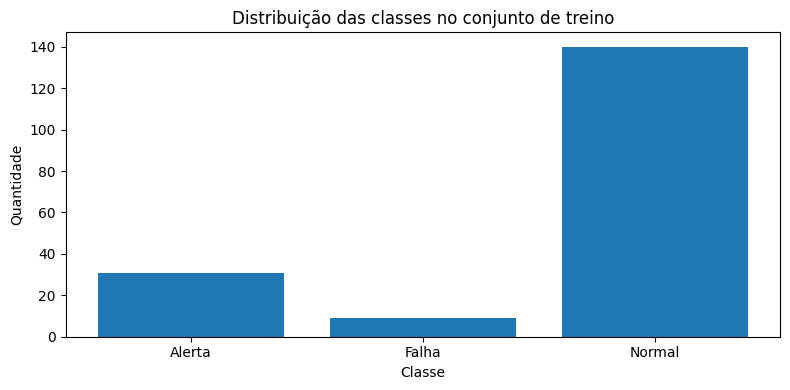

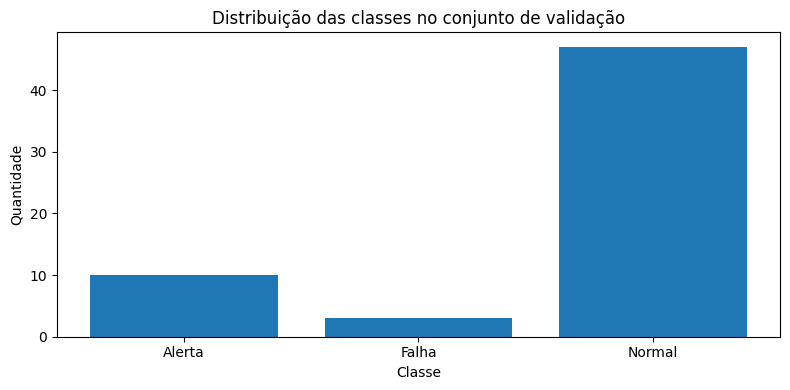

In [189]:

import matplotlib.pyplot as plt

# 1. Correção no cálculo das frequências das classes:
train_counts = y_train.value_counts().sort_index()
val_counts = y_val.value_counts().sort_index()

# 2. Gráfico do conjunto de treino:
plt.figure(figsize=(8, 4))
plt.bar(train_counts.index, train_counts.values)
plt.title("Distribuição das classes no conjunto de treino")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

# 3. Gráfico do conjunto de validação:
plt.figure(figsize=(8, 4))
plt.bar(val_counts.index, val_counts.values)
plt.title("Distribuição das classes no conjunto de validação")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

### Reflexão
- Qual é a função do conjunto de treino?
- Qual é a função do conjunto de validação?
- O que significa preservar a proporção das classes?


## 5. Criação do modelo supervisionado

In [190]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

# Definindo a Pipeline
modelo_supervisionado = Pipeline([
    ("preprocessamento", StandardScaler()),
    ("modelo", DecisionTreeClassifier(max_depth=4, random_state=42))
])

# Exibindo a estrutura da Pipeline
(modelo_supervisionado)

Pipeline(steps=[('preprocessamento', StandardScaler()),
                ('modelo',
                 DecisionTreeClassifier(max_depth=4, random_state=42))])

## 6. Treino, validação e métricas

In [191]:
from sklearn.metrics import classification_report, accuracy_score

modelo_supervisionado = Pipeline([
    ('preprocessamento', preprocessador),
    ('modelo', DecisionTreeClassifier(max_depth=4, random_state=42)),
])

modelo_supervisionado.fit(X_train, y_train)

pred_supervisionado = modelo_supervisionado.predict(X_val)
acc = accuracy_score(y_val, pred_supervisionado)

print("Acurácia na validação:", round(acc, 4))
print("\nRelatório de classificação:")
print(classification_report(y_val, pred_supervisionado))

Acurácia na validação: 1.0

Relatório de classificação:
              precision    recall  f1-score   support

      Alerta       1.00      1.00      1.00        10
       Falha       1.00      1.00      1.00         3
      Normal       1.00      1.00      1.00        47

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



###Anatomia da metricas auxiliares do modelo preditivo

In [192]:
relatorio = classification_report(
    y_val,
    pred_supervisionado,
    output_dict=True
)

print("ACURÁCIA")
print(f"Valor: {acc:.2%}")
print("Indica o percentual geral de previsões que o modelo acertou.")


print("\n===== CLASSE ALERTA =====")

print(f"Precision: {relatorio['Alerta']['precision']:.2f}")
print("Indica, entre todas as previsões de Alerta, quantas estavam realmente corretas.")

print(f"Recall: {relatorio['Alerta']['recall']:.2f}")
print("Indica, entre todos os casos que realmente eram Alerta, quantos o modelo conseguiu identificar.")

print(f"F1-score: {relatorio['Alerta']['f1-score']:.2f}")
print("Representa o equilíbrio entre Precision e Recall. Quanto maior, melhor o desempenho.")

print(f"Support: {relatorio['Alerta']['support']}")
print("Indica a quantidade de casos reais da classe Alerta na validação.")


print("\n===== CLASSE FALHA =====")

print(f"Precision: {relatorio['Falha']['precision']:.2f}")
print("Indica, entre todas as previsões de Falha, quantas estavam realmente corretas.")

print(f"Recall: {relatorio['Falha']['recall']:.2f}")
print("Indica, entre todos os casos que realmente eram Falha, quantos o modelo conseguiu identificar.")

print(f"F1-score: {relatorio['Falha']['f1-score']:.2f}")
print("Representa o equilíbrio entre Precision e Recall.")

print(f"Support: {relatorio['Falha']['support']}")
print("Indica a quantidade de casos reais da classe Falha na validação.")


print("\n===== CLASSE NORMAL =====")

print(f"Precision: {relatorio['Normal']['precision']:.2f}")
print("Indica, entre todas as previsões de Normal, quantas estavam realmente corretas.")

print(f"Recall: {relatorio['Normal']['recall']:.2f}")
print("Indica, entre todos os casos que realmente eram Normal, quantos o modelo conseguiu identificar.")

print(f"F1-score: {relatorio['Normal']['f1-score']:.2f}")
print("Representa o equilíbrio entre Precision e Recall.")

print(f"Support: {relatorio['Normal']['support']}")
print("Indica a quantidade de casos reais da classe Normal na validação.")

print("\n===== ACCURACY =====")
print(f"Accuracy: {acc:.2f}")
print("Representa o percentual geral de previsões que o modelo acertou.")
print(f"Quantidade de casos avaliados: {len(y_val)}")
print("Indica quantos registros foram utilizados para calcular a acurácia.")


print("\n===== MACRO AVG =====")
print(f"Precision: {relatorio['macro avg']['precision']:.2f}")
print("É a média da Precision das classes Alerta, Falha e Normal, dando o mesmo peso para cada classe.")

print(f"Recall: {relatorio['macro avg']['recall']:.2f}")
print("É a média do Recall das classes, considerando todas as classes com o mesmo peso.")

print(f"F1-score: {relatorio['macro avg']['f1-score']:.2f}")
print("É a média dos F1-scores das três classes, dando o mesmo peso para cada classe.")

print(f"Support: {relatorio['macro avg']['support']}")
print("Representa o total de registros utilizados na avaliação.")


print("\n===== WEIGHTED AVG =====")
print(f"Precision: {relatorio['weighted avg']['precision']:.2f}")
print("É a média da Precision considerando a quantidade de exemplos de cada classe.")

print(f"Recall: {relatorio['weighted avg']['recall']:.2f}")
print("É a média do Recall considerando a quantidade de exemplos de cada classe.")

print(f"F1-score: {relatorio['weighted avg']['f1-score']:.2f}")
print("É a média do F1-score considerando a quantidade de exemplos de cada classe.")

print(f"Support: {relatorio['weighted avg']['support']}")
print("Representa o total de registros utilizados na avaliação.")

ACURÁCIA
Valor: 100.00%
Indica o percentual geral de previsões que o modelo acertou.

===== CLASSE ALERTA =====
Precision: 1.00
Indica, entre todas as previsões de Alerta, quantas estavam realmente corretas.
Recall: 1.00
Indica, entre todos os casos que realmente eram Alerta, quantos o modelo conseguiu identificar.
F1-score: 1.00
Representa o equilíbrio entre Precision e Recall. Quanto maior, melhor o desempenho.
Support: 10.0
Indica a quantidade de casos reais da classe Alerta na validação.

===== CLASSE FALHA =====
Precision: 1.00
Indica, entre todas as previsões de Falha, quantas estavam realmente corretas.
Recall: 1.00
Indica, entre todos os casos que realmente eram Falha, quantos o modelo conseguiu identificar.
F1-score: 1.00
Representa o equilíbrio entre Precision e Recall.
Support: 3.0
Indica a quantidade de casos reais da classe Falha na validação.

===== CLASSE NORMAL =====
Precision: 1.00
Indica, entre todas as previsões de Normal, quantas estavam realmente corretas.
Recall: 

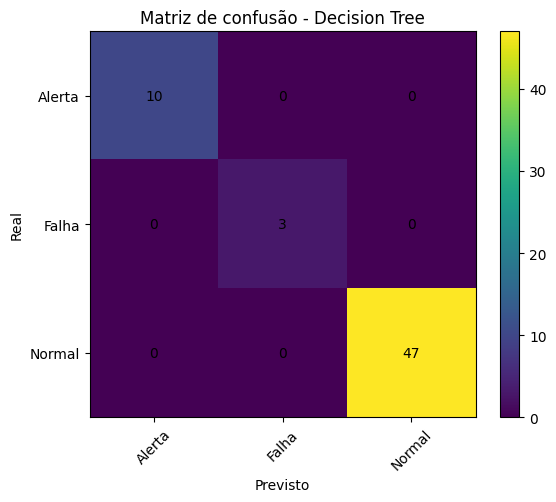

In [193]:
from sklearn.metrics import confusion_matrix

labels = sorted(y.unique())
cm = confusion_matrix(y_val, pred_supervisionado, labels=labels)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Matriz de confusão - Decision Tree")
plt.colorbar()
plt.xticks(range(len(labels)), labels, rotation=45)
plt.yticks(range(len(labels)), labels)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Previsto")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

### Explicação da Matriz de Confusão

In [194]:
print("\n===== INTERPRETAÇÃO DA MATRIZ DE CONFUSÃO =====")

print(f"Alerta: havia {cm[0].sum()} casos reais.")
print(
    f"O modelo acertou {cm[0, 0]} e classificou {cm[0, 1]} como Falha e"
    f" {cm[0, 2]} como Normal. Errou 9"
)

print(f"\nFalha: havia {cm[1].sum()} casos reais.")
print(
    f"O modelo acertou {cm[1, 1]} e classificou {cm[1, 0]} como Alerta e"
    f" {cm[1, 2]} como Normal. Errou tudo"
)

print(f"\nNormal: havia {cm[2].sum()} casos reais.")
print(
    f"O modelo acertou {cm[2, 2]} e classificou {cm[2, 0]} como Alerta e"
    f" {cm[2, 1]} como Falha."
)

print("\nConclusão:")
print(f"O modelo acertou {cm[0, 0] + cm[1, 1] + cm[2, 2]} de {cm.sum()} casos.")
print("O modelo apresenta melhor desempenho na identificação da classe Normal.")


===== INTERPRETAÇÃO DA MATRIZ DE CONFUSÃO =====
Alerta: havia 10 casos reais.
O modelo acertou 10 e classificou 0 como Falha e 0 como Normal. Errou 9

Falha: havia 3 casos reais.
O modelo acertou 3 e classificou 0 como Alerta e 0 como Normal. Errou tudo

Normal: havia 47 casos reais.
O modelo acertou 47 e classificou 0 como Alerta e 0 como Falha.

Conclusão:
O modelo acertou 60 de 60 casos.
O modelo apresenta melhor desempenho na identificação da classe Normal.


### Reflexão
- Qual foi a acurácia obtida?
- Em quais classes o modelo parece ter acertado mais?
- Onde houve confusão?


## 7. Demonstração não supervisionada

### Pergunta de negócio

>"Podemos identificar perfis distintos de operação no processo industrial, agrupando equipamentos ou situações com características semelhantes para apoiar decisões de monitoramento e controle?"</br>
Ou</br>
>Quais são os diferentes perfis de operação existentes no processo industrial?

In [195]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

X_cluster = df.drop(columns=["status_instrumentacao", "acao_ideal_controle"]).copy()

colunas_numericas_cluster = X_cluster.select_dtypes(include=["number"]).columns.tolist()
colunas_categoricas_cluster = X_cluster.select_dtypes(include=["object"]).columns.tolist()

preprocessador_cluster = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            ("scaler", StandardScaler())
        ]), colunas_numericas_cluster),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), colunas_categoricas_cluster)
    ]
)

X_cluster_transformado = preprocessador_cluster.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster_transformado)

sil = silhouette_score(X_cluster_transformado, clusters)

print("Silhouette Score:", round(sil, 4))
print(pd.Series(clusters).value_counts().sort_index())

Silhouette Score: 0.0761
0    107
1     71
2     62
Name: count, dtype: int64


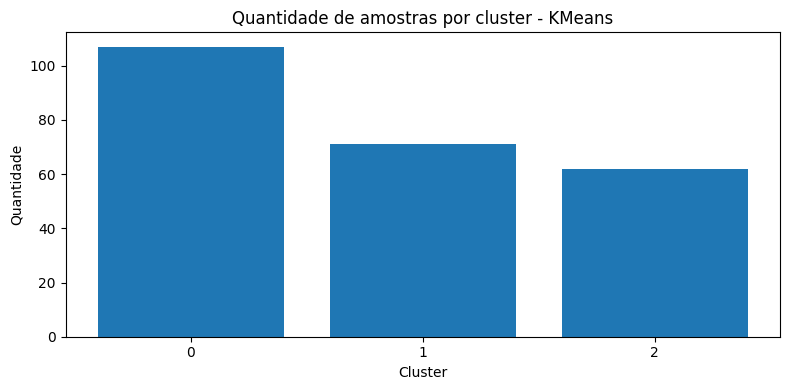

In [196]:
cluster_counts = pd.Series(clusters).value_counts().sort_index()

plt.figure(figsize=(8,4))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values)
plt.title("Quantidade de amostras por cluster - KMeans")
plt.xlabel("Cluster")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

| Silhouette       | Interpretação                      |
| ---------------- | ---------------------------------- |
| próximo de **1** | 🟢 Grupos muito bem separados      |
| próximo de **0** | 🟡 Grupos muito semelhantes        |
| negativo         | 🔴 Possível agrupamento inadequado |

### Reflexão
- O que o KMeans está tentando encontrar?
- Por que ele não precisa da variável-alvo?


## 8. Demonstração semi-supervisionada

### Pergunta de negócio

>"Podemos identificar o status da instrumentação em registros que não foram classificados, utilizando como referência os padrões encontrados em registros já classificados?"

In [197]:
from sklearn.preprocessing import LabelEncoder # Add this import statement
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.semi_supervised import LabelSpreading # Add this import statement
import numpy as np # Add this import statement
from sklearn.metrics import accuracy_score # Add this import statement

X_semi = df.drop(columns=["status_instrumentacao", "acao_ideal_controle"])
y_semi = df["status_instrumentacao"].copy()

colunas_numericas_semi = X_semi.select_dtypes(include=["number"]).columns.tolist()
colunas_categoricas_semi = X_semi.select_dtypes(include=["object"]).columns.tolist()

preprocessador_semi = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            ("scaler", StandardScaler())
        ]), colunas_numericas_semi),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), colunas_categoricas_semi)
    ]
)

X_semi_transformado = preprocessador_semi.fit_transform(X_semi)
# print("Dados originais:", X_semi.shape)
# print("Dados após transformação:", X_semi_transformado.shape)

# print("\nPrimeiros 5 registros transformados:")
# print(X_semi_transformado[:5])

label_encoder = LabelEncoder()
y_codificado = label_encoder.fit_transform(y_semi)
# print(f"y_semi===> {y_semi}")

rng = np.random.default_rng(42)
# print("\nrng cria um gerador de números aleatórios. O 42 define uma semente para que o sorteio possa ser reproduzido sempre da mesma maneira.")

#copie o valor do objeto y_codificado usando copy()
y_parcial = y_codificado.copy()
indices_sem_rotulo = rng.choice(len(y_parcial), size=int(len(y_parcial) * 0.6), replace=False)

#print(f"indices_sem_rotulo==> {indices_sem_rotulo}")
#print(f"\ny_parcial antes==> {y_parcial}")

y_parcial[indices_sem_rotulo] = -1

#print(f"\ny_parcial depois==> {y_parcial}")

modelo_semi = LabelSpreading(kernel="knn", n_neighbors=7)
#print("Treina o modelo semissupervisionado usando os dados e os rótulos disponíveis.")
modelo_semi.fit(X_semi_transformado, y_parcial)

#print("retorna os rótulos finais que o LabelSpreading atribuiu a todos os registros depois do aprendizado.")
rotulos_previstos = modelo_semi.transduction_

mascara_rotulada = y_parcial != -1
mascara_nao_rotulada = y_parcial == -1

acc_rot = accuracy_score(y_codificado[mascara_rotulada], rotulos_previstos[mascara_rotulada])
acc_nao_rot = accuracy_score(y_codificado[mascara_nao_rotulada], rotulos_previstos[mascara_nao_rotulada])

print("Acurácia nas amostras rotuladas:", round(acc_rot, 4))
print("Acurácia nas amostras sem rótulo para o algoritmo:", round(acc_nao_rot, 4))

Acurácia nas amostras rotuladas: 1.0
Acurácia nas amostras sem rótulo para o algoritmo: 0.7847


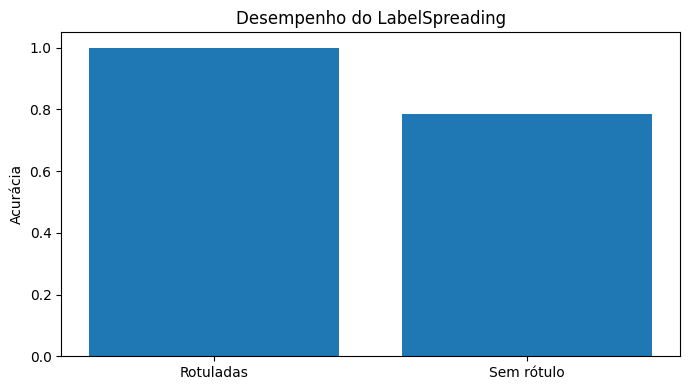

In [198]:
plt.figure(figsize=(7,4))
plt.bar(["Rotuladas", "Sem rótulo"], [acc_rot, acc_nao_rot])
plt.title("Desempenho do LabelSpreading")
plt.ylabel("Acurácia")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

### Resumindo cada etapa:

1. **Identifica os tipos de dados**

```python
colunas_numericas_semi
colunas_categoricas_semi
```

→ Separa as colunas **numéricas** das **categóricas**.

2. **Prepara os dados**

```python
preprocessador_semi
```

→ Corrige valores vazios, padroniza números e transforma categorias em números.

3. **Transforma os dados**

```python
X_semi_transformado
```

→ Deixa os dados prontos para o algoritmo.

4. **Transforma os rótulos em números**

```python
y_codificado
```

→ Por exemplo: `Normal = 0`, `Alerta = 1`, `Falha = 2`.

5. **Remove 60% dos rótulos**

```python
y_parcial[indices_sem_rotulo] = -1
```

→ Simula uma situação onde **60% dos dados não possuem classificação conhecida** aplica o valor -1 para 60% dos valores do array y_parcial. É uma das partes mais importantes da etapa do aprendizado semi-supervisionado!

6. **Aplica o LabelSpreading**

```python
LabelSpreading(kernel="knn", n_neighbors=7)
```

→ Usa os **7 vizinhos mais próximos** para tentar descobrir os rótulos dos dados que ficaram sem classificação.

7. **Compara os resultados**

```python
acc_rot
acc_nao_rot
```

→ Calcula:
* **Acurácia dos dados que tinham rótulo**
* **Acurácia dos dados que estavam sem rótulo e foram previstos pelo algoritmo**



### **Conclusão**

> **O código pega os dados, esconde os rótulos de 60% deles e testa se o LabelSpreading consegue descobrir corretamente esses rótulos usando a semelhança entre os registros.**


### Reflexão
- O que muda quando parte dos rótulos é escondida?
- Qual é a vantagem desse tipo de abordagem?


## 9. Demonstração da lógica do reforço

### Pergunta de negócio

>"Qual estratégia de controle pode tomar melhores decisões para corrigir o erro de vazão e maximizar o resultado operacional do processo?"

In [199]:
acoes_possiveis = ["Aumentar_Abertura", "Manter_Ajuste", "Reduzir_Abertura"]

df_rl = df[["erro_vazao_pct", "acao_ideal_controle"]].copy()

rng = np.random.default_rng(42)
acoes_aleatorias = rng.choice(acoes_possiveis, size=len(df_rl))
# print(f"Mostrar algumas acoes_aleatorias ==> {acoes_aleatorias[:5]}, {len( acoes_aleatorias)}")

df_rl["acao_agente_aleatorio"] = acoes_aleatorias
df_rl["recompensa_aleatoria"] = np.where(
    df_rl["acao_agente_aleatorio"] == df_rl["acao_ideal_controle"], 1, -1
)

# print(f"Mostrar novas colunas de df_rl: {df_rl[["acao_agente_aleatorio","recompensa_aleatoria"]].head(10)} ")

#Significado de Heurística = uma regra prática para decidir o que fazer com base em uma situação.
def politica_heuristica(erro):
    if erro < -3:
        return "Aumentar_Abertura"
    elif erro > 3:
        return "Reduzir_Abertura"
    else:
        return "Manter_Ajuste"
    # if erro < -5:
    #     return "Aumentar_Abertura"
    # elif erro > 5:
    #     return "Reduzir_Abertura"
    # else:
    #     return "Manter_Ajuste"

#print("Pega cada valor da coluna erro_vazao_pct, aplica a função politica_heuristica e salva o resultado em uma nova coluna chamada acao_heuristica.")
df_rl["acao_heuristica"] = df_rl["erro_vazao_pct"].apply(politica_heuristica)
df_rl["recompensa_heuristica"] = np.where(
    df_rl["acao_heuristica"] == df_rl["acao_ideal_controle"], 1, -1
)

recompensa_total_agente = df_rl["recompensa_aleatoria"].sum()
recompensa_total_heuristica = df_rl["recompensa_heuristica"].sum()

print("Recompensa total do agente aleatório:", recompensa_total_agente)
print("Recompensa total da heurística:", recompensa_total_heuristica)

Recompensa total do agente aleatório: -64
Recompensa total da heurística: 240


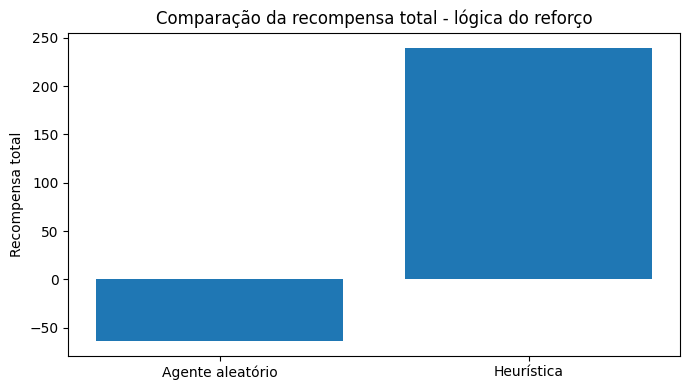

In [200]:
plt.figure(figsize=(7,4))
plt.bar(["Agente aleatório", "Heurística"], [recompensa_total_agente, recompensa_total_heuristica])
plt.title("Comparação da recompensa total - lógica do reforço")
plt.ylabel("Recompensa total")
plt.tight_layout()
plt.show()

### Reflexão
- O que representa o estado?
- O que representa a ação?
- O que representa a recompensa?
- Por que essa lógica é diferente dos outros tipos de aprendizado?


## 10. Comparação visual final

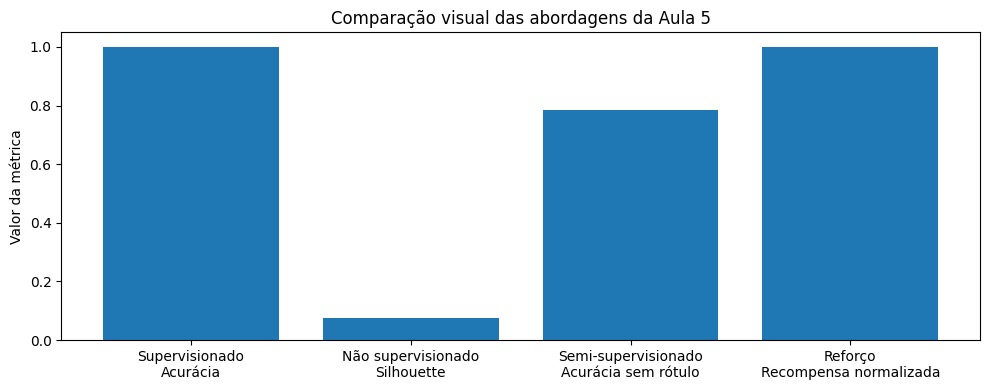

In [201]:
metricas = {
    "Supervisionado\nAcurácia": acc,
    "Não supervisionado\nSilhouette": sil,
    "Semi-supervisionado\nAcurácia sem rótulo": acc_nao_rot,
    "Reforço\nRecompensa normalizada": recompensa_total_heuristica / len(df)
}

plt.figure(figsize=(10,4))
plt.bar(list(metricas.keys()), list(metricas.values()))
plt.title("Comparação visual das abordagens da Aula 5")
plt.ylabel("Valor da métrica")
plt.tight_layout()
plt.show()

###***EXTRA***
* Testar Resultados com IA Generativa

> Aqui buscamos apoio da IA Genrativa para checarmos se nossas analises se convergem, utilizamos a IA para validar/respaldar/aprimorar nossas habilidades analiticas e para apresentar um relatorio de alto nível

In [202]:
!pip install -q groq


In [203]:
from groq import Groq
from google.colab import files
import base64

from google.colab import userdata
groq_api_key= userdata.get('groq.API')

client = Groq(api_key=groq_api_key)

def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(
            image_file.read()
        ).decode("utf-8")

In [ ]:
arquivo = files.upload()
nome_arquivo = list(arquivo.keys())[0]
print("Arquivo selecionado:", nome_arquivo)
base64_image = encode_image(nome_arquivo)

In [ ]:
prompt= input("Digite aqui sua pergunta===>")
display(prompt)

In [ ]:

response = client.chat.completions.create(
    model="qwen/qwen3.8-27b",
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": f"{prompt}"
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/png;base64,{base64_image}"
                    }
                }
            ]
        }
    ],
    temperature=0,

)

print(response.choices[0].message.content)

## 11. Registro final do aluno

Preencha:
- Qual tipo de aprendizado é mais adequado ao projeto atual?
- Qual abordagem poderia complementar a análise?
- O que você entendeu sobre preparação dos dados, treino, validação e métricas?
